In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.constants as sc
import skrf as rf
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Configuração para gráficos interativos se estiver no Jupyter (opcional)
# %matplotlib notebook 

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [12]:
class CavidadeRetangular:
    def __init__(self, a, b, d, er=1.0, tand=0.0, sigma=5.8e7):
        """
        a, b, d: Dimensões em metros (x, y, z)
        er: Permissividade relativa do dielétrico
        tand: Tangente de perdas do dielétrico
        sigma: Condutividade das paredes metálicas (S/m)
        """
        self.a = a
        self.b = b
        self.d = d
        self.er = er
        self.tand = tand
        self.sigma = sigma
        
        # Constantes fundamentais
        self.mu_0 = sc.mu_0
        self.epsilon_0 = sc.epsilon_0
        self.c = sc.c / np.sqrt(er)
        
    def freq_ressonancia(self, m, n, l):
        """Calcula a frequência de ressonância analítica para o modo (m,n,l)"""
        kx = m * np.pi / self.a
        ky = n * np.pi / self.b
        beta = l * np.pi / self.d
        f_res = (self.c / (2 * np.pi)) * np.sqrt(kx**2 + ky**2 + beta**2)
        return f_res

    def calcular_Q(self, m, n, l):
        """Calcula os fatores de qualidade (Q_cond, Q_die, Q_total) para modos TE_mnl"""
        f0 = self.freq_ressonancia(m, n, l)
        w0 = 2 * np.pi * f0
        
        # Q do Dielétrico
        Q_die = 1.0 / self.tand if self.tand > 0 else float('inf')
        
        # Q de Condução (Aproximação para o modo dominante TE101)
        rs = np.sqrt((w0 * self.mu_0) / (2 * self.sigma))
        eta = 377 / np.sqrt(self.er)
        k = w0 / self.c
        
        # Ajuste simplificado clássico para o modo TE101:
        if m==1 and n==0 and l==1:
            num = (self.c * self.mu_0 * np.pi) * (self.a**3 * self.b * self.d**3) * ( (1/self.a**2) + (1/self.d**2) )**(1.5)
            den = 4 * rs * ( (self.a**3 * self.b) + (self.d**3 * self.b) + 0.5*(self.a**3 * self.d) + 0.5*(self.a * self.d**3) )
            Q_cond = num / den
        else:
            # Fallback genérico proporcional
            Q_cond = 2 * (w0 * self.mu_0) / (rs * (2/self.b + 2/self.a + 2/self.d))
            
        if Q_die == float('inf'):
            Q_total = Q_cond
        else:
            Q_total = 1 / (1/Q_cond + 1/Q_die)
            
        return Q_cond, Q_die, Q_total

# ==========================================
# 2. FUNÇÕES DE PLOTAGEM (FORA DA CLASSE)
# ==========================================
def plotar_geometria_cavidade(cavidade):
    """Plota a estrutura 3D da cavidade e a localização conceitual das portas"""
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    a, b, d = cavidade.a, cavidade.b, cavidade.d
    
    # Definição dos vértices do cubo (cavidade)
    vertices = np.array([
        [0, 0, 0], [a, 0, 0], [a, b, 0], [0, b, 0],
        [0, 0, d], [a, 0, d], [a, b, d], [0, b, d]
    ])
    
    # Definição das 6 faces metálicas
    faces = [
        [vertices[0], vertices[1], vertices[2], vertices[3]], # Base (z=0)
        [vertices[4], vertices[5], vertices[6], vertices[7]], # Topo (z=d)
        [vertices[0], vertices[1], vertices[5], vertices[4]], # Frente (y=0)
        [vertices[2], vertices[3], vertices[7], vertices[6]], # Trás (y=b)
        [vertices[0], vertices[3], vertices[7], vertices[4]], # Esquerda (x=0)
        [vertices[1], vertices[2], vertices[6], vertices[5]]  # Direita (x=a)
    ]
    
    # Desenha as paredes da cavidade (semi-transparentes para ver o interior)
    ax.add_collection3d(Poly3DCollection(faces, facecolors='cyan', linewidths=1, edgecolors='darkcyan', alpha=0.15))
    
    # Destacar as Portas de Excitação (Íris centralizadas nas faces z=0 e z=d)
    p1 = np.array([[a/2 - a*0.15, b/2 - b*0.15, 0], [a/2 + a*0.15, b/2 - b*0.15, 0], 
                   [a/2 + a*0.15, b/2 + b*0.15, 0], [a/2 - a*0.15, b/2 + b*0.15, 0]])
    p2 = np.array([[a/2 - a*0.15, b/2 - b*0.15, d], [a/2 + a*0.15, b/2 - b*0.15, d], 
                   [a/2 + a*0.15, b/2 + b*0.15, d], [a/2 - a*0.15, b/2 + b*0.15, d]])
    
    ax.add_collection3d(Poly3DCollection([p1], facecolors='red', edgecolors='r', alpha=0.8))
    ax.add_collection3d(Poly3DCollection([p2], facecolors='orange', edgecolors='orange', alpha=0.8))
    
    # Configurações de exibição
    ax.set_title("Geometria da Cavidade Retangular e Portas de Excitação")
    ax.set_xlabel('Largura (a) [m]')
    ax.set_ylabel('Altura (b) [m]')
    ax.set_zlabel('Comprimento (d) [m]')
    ax.set_xlim(0, a)
    ax.set_ylim(0, b)
    ax.set_zlim(0, d)
    
    # Legenda manual para as portas
    legend_elements = [patches.Patch(color='red', alpha=0.8, label='Porta 1 (Acoplamento Entrada - z=0)'),
                       patches.Patch(color='orange', alpha=0.8, label='Porta 2 (Acoplamento Saída - z=d)')]
    ax.legend(handles=legend_elements, loc='upper left')
    plt.show()



In [13]:
def plotar_cortes_campo_te101(cavidade):
    """Plota mapas de cores (colormaps) do módulo do campo elétrico em cortes estratégicos"""
    x = np.linspace(0, cavidade.a, 200)
    y = np.linspace(0, cavidade.b, 100)
    z = np.linspace(0, cavidade.d, 200)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # ----------------------------------------------------
    # PLANO 1: Corte Horizontal no meio da altura (y = b/2) -> Plano XZ
    # ----------------------------------------------------
    X_xz, Z_xz = np.meshgrid(x, z)
    Ey_xz = np.sin(np.pi * X_xz / cavidade.a) * np.sin(np.pi * Z_xz / cavidade.d)
    magnitude_xz = np.abs(Ey_xz)
    
    im1 = ax1.pcolormesh(Z_xz, X_xz, magnitude_xz, shading='auto', cmap='jet')
    ax1.set_title("Magnitude de $|E|$ no Plano XZ (Corte em $y = b/2$)")
    ax1.set_xlabel("Comprimento (z) [m]")
    ax1.set_ylabel("Largura (x) [m]")
    fig.colorbar(im1, ax=ax1, label="Intensidade Relativa do Campo")
    
    # ----------------------------------------------------
    # PLANO 2: Corte Transversal no meio do comprimento (z = d/2) -> Plano XY
    # ----------------------------------------------------
    X_xy, Y_xy = np.meshgrid(x, y)
    Ey_xy = np.sin(np.pi * X_xy / cavidade.a) * np.sin(np.pi * (cavidade.d/2) / cavidade.d)
    magnitude_xy = np.abs(Ey_xy)
    
    im2 = ax2.pcolormesh(X_xy, Y_xy, magnitude_xy, shading='auto', cmap='jet')
    ax2.set_title("Magnitude de $|E|$ no Plano XY (Corte em $z = d/2$)")
    ax2.set_xlabel("Largura (x) [m]")
    ax2.set_ylabel("Altura (b) [m]")
    fig.colorbar(im2, ax=ax2, label="Intensidade Relativa do Campo")
    
    plt.tight_layout()
    plt.show()

In [14]:
def plotar_parametros_s(cavidade, m=1, n=0, l=1, fc_span=0.05e9):
    f0 = cavidade.freq_ressonancia(m, n, l)
    _, _, Q = cavidade.calcular_Q(m, n, l)
    
    # Vetor de frequências ao redor da ressonância
    freqs = np.linspace(f0 - fc_span, f0 + fc_span, 1000)
    
    # Modelo analítico de uma cavidade de transmissão (Lorentziana / RLC paralelo acoplado)
    # Supõe um acoplamento fraco (perto de 0 dB de perda de inserção na ressonância para simplificação)
    s21 = 1 / (1 + 1j * Q * (freqs / f0 - f0 / freqs))
    s11 = np.sqrt(1 - np.abs(s21)**2) # Cavidade sem perdas externas críticas
    
    # Criar objeto Network do scikit-rf
    ntw = rf.Network()
    ntw.f = freqs
    ntw.s = np.zeros((len(freqs), 2, 2), dtype=complex)
    ntw.s[:, 0, 0] = s11
    ntw.s[:, 1, 0] = s21
    ntw.s[:, 0, 1] = s21
    ntw.s[:, 1, 1] = s11
    
    # Plotar usando o scikit-rf
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    ntw.plot_s_db(m=1, n=0, label="$S_{21}$ (Transmissão)")
    ntw.plot_s_db(m=0, n=0, label="$S_{11}$ (Reflexão)")
    plt.title("Parâmetros S (dB)")
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    ntw.plot_s_smith(m=0, n=0)
    plt.title("Carta de Smith ($S_{11}$)")
    
    plt.tight_layout()
    plt.show()

Modo Dominante TE101: 5.005 GHz



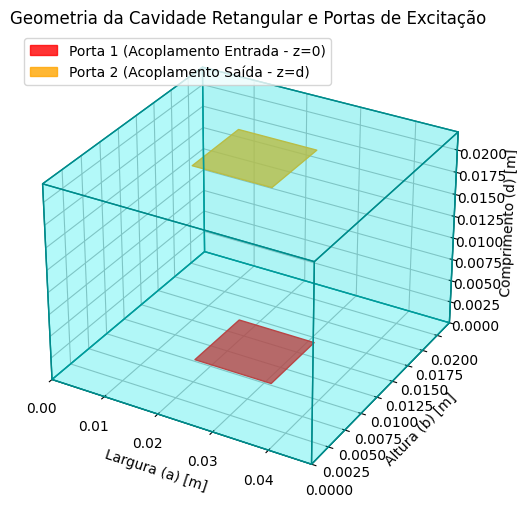

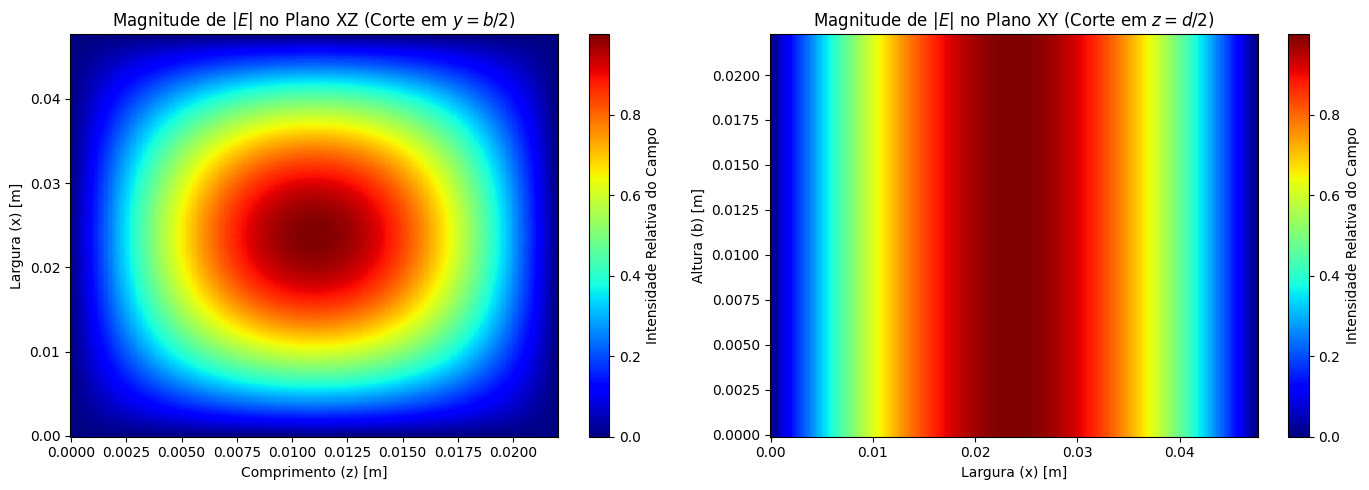

C:\Users\filip\AppData\Local\Temp\ipykernel_124472\437814178.py:15: DeprecationWarning: frequency.f parameter will be immutable in the next release.
  ntw.f = freqs


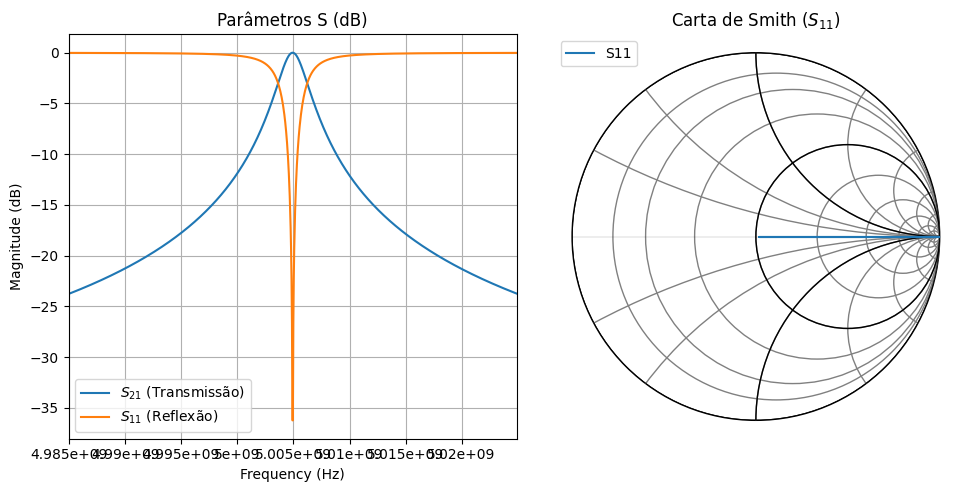

In [15]:
# Dimensões (Exemplo H-Band do Pozar)
a_cm, b_cm, d_cm = 4.755, 2.215, 2.20
er = 2.25
tangente_perdas = 4e-4
condutividade_cobre = 5.8e7

# Instanciando o objeto cavidade
cav = CavidadeRetangular(a=a_cm*sc.centi, b=b_cm*sc.centi, d=d_cm*sc.centi, 
                         er=er, tand=tangente_perdas, sigma=condutividade_cobre)

print(f"Modo Dominante TE101: {cav.freq_ressonancia(1, 0, 1)/1e9:.3f} GHz\n")

# Executando os plots sequencialmente
plotar_geometria_cavidade(cav)
plotar_cortes_campo_te101(cav)
plotar_parametros_s(cav, m=1, n=0, l=1, fc_span=0.02e9)